# 🧹 NLP: Text Preprocessing 

## 1. Lowercasing

Convert all text to lowercase to ensure uniformity.

**Why?**  
Words like "Apple" and "apple" are treated as different. Lowercasing avoids this duplication.

**Code:**

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
# For a single string
text = "Hello World"
text = text.lower()
text
# For a pandas column
# df['text'] = df['text'].str.lower()

'hello world'

## 2. Removing HTML Tags

HTML tags add no semantic meaning for text analysis and must be removed to clean the data for further processing such as tokenization, keyword extraction, or machine learning tasks.

### ✅ Why Remove HTML Tags?
- They interfere with textual analysis.
- They add noise to the actual content.
- Most NLP models don't need HTML tags to understand the text.

### 🧹 Example Code to Remove HTML Tags in Python

In [3]:
import re

def remove_html_tags(text):
    clean = re.compile('<.*?>')
    return re.sub(clean, '', text)

# Example usage
html_text = "<p>Hello, <b>world</b>! Welcome to <a href='#'>AI</a>.</p>"
clean_text = remove_html_tags(html_text)
print(clean_text)

Hello, world! Welcome to AI.


## 3. Removing URLs

URLs are often irrelevant and add noise to the dataset, especially in tasks like sentiment analysis or topic modeling.

**Why?**  
They typically don’t contribute meaningful semantic content and may skew model training.

**Code:**

In [4]:
import re

# For a single string
def remove_urls(text):
    return re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

text = "Visit our site at https://example.com or http://example.org"
clean_text = remove_urls(text)
clean_text
# For a pandas column
# df['text'] = df['text'].apply(lambda x: re.sub(r'http\S+|www\S+|https\S+', '', x))

'Visit our site at  or '

## 4. Removing Punctuation

Punctuation can distort tokenization and model learning, especially in tasks like word frequency analysis or vectorization.

**Why?**  
Most NLP models treat punctuation as noise unless you're doing syntax-based tasks like POS tagging or parsing.

**Code:**

In [5]:
import string

# For a single string
def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))

text = "Hello, world! NLP is amazing."
clean_text = remove_punctuation(text)
clean_text
# For a pandas column
# df['text'] = df['text'].apply(lambda x: x.translate(str.maketrans('', '', string.punctuation)))

'Hello world NLP is amazing'

## 5. Handling Chat Words

Chat abbreviations like "lol", "brb", "idk" should be expanded to their full forms to improve semantic understanding.

**Why?**  
Expanding chat words helps models better understand the meaning behind informal language often used in social media, chats, and forums.

**Code**

In [6]:
# Define a dictionary of common chat words
chat_words = {
    "lol": "laughing out loud",
    "brb": "be right back",
    "idk": "I don't know",
    "omg": "oh my god",
    "ttyl": "talk to you later",
    "btw": "by the way"
}

# Function to replace chat words in text
def expand_chat_words(text):
    words = text.split()
    expanded_words = [chat_words.get(word.lower(), word) for word in words]
    return ' '.join(expanded_words)

text = "lol idk what to do brb"
clean_text = expand_chat_words(text)
clean_text
# For a pandas column
# df['text'] = df['text'].apply(expand_chat_words)


"laughing out loud I don't know what to do be right back"

## 6. Spelling Correction

Correcting typos improves understanding and reduces noise, leading to better text representation and model performance.

**Why?**  
Misspelled words can reduce the effectiveness of token matching, embeddings, and overall model accuracy.

**Code:**

In [7]:
pip install "numpy<1.28.0"


Note: you may need to restart the kernel to use updated packages.


In [8]:
from textblob import TextBlob

# For a single string
def correct_spelling(text):
    return str(TextBlob(text).correct())

text = "I havv goood speling."
corrected_text = correct_spelling(text)
corrected_text
# For a pandas column (use with caution on large datasets due to speed)
# df['text'] = df['text'].apply(lambda x: str(TextBlob(x).correct()))


'I have good spelling.'

## 7. Stopword Removal

Stopwords (e.g. "the", "is", "in") are common words with little meaning and are often removed to focus on meaningful content.

⚠️ Note: Avoid stopword removal before POS tagging, as it may affect grammatical structure.

**Why?**  
Removing stopwords helps reduce dimensionality and focuses the model on informative words.

**Code:**


In [9]:

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk

# Download stopwords if not already present
nltk.download('stopwords')
nltk.download('punkt')

# Define stop words
stop_words = set(stopwords.words('english'))

# For a single string
def remove_stopwords(text):
    tokens = word_tokenize(text)
    filtered = [word for word in tokens if word.lower() not in stop_words]
    return ' '.join(filtered)

text = "This is an example showing off stop word filtration."
clean_text = remove_stopwords(text)
clean_text
# For a pandas column
# df['text'] = df['text'].apply(remove_stopwords)


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\goura\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\goura\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


'example showing stop word filtration .'

## 8. Handling Emojis

Emojis can be either removed or replaced with their textual meaning based on the use case.

**Why?**  
- Emojis may add noise in formal text analysis.
- Alternatively, they can provide emotional or contextual cues useful in sentiment analysis.

**Options:**
- ❌ Remove emojis
- 🔄 Replace emojis with their meaning (e.g., 😊 → "smiling face")

**Code:**


In [10]:
import emoji
import re

# Option 1: Remove emojis
def remove_emojis(text):
    emoji_pattern = re.compile("["
                           u"\U0001F600-\U0001F64F"  # emoticons
                           u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                           u"\U0001F680-\U0001F6FF"  # transport & map symbols
                           u"\U0001F1E0-\U0001F1FF"  # flags
                           "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r'', text)

# Option 2: Replace emojis with their meaning
def replace_emojis(text):
    return emoji.demojize(text, language='en')  # Converts 😊 to :smiling_face_with_smiling_eyes:

# Examples
text = "I love NLP! 😊🚀"

removed = remove_emojis(text)
replaced = replace_emojis(text)
replaced
# # For a pandas column
# df['text_no_emoji'] = df['text'].apply(remove_emojis)
# df['text_with_labels'] = df['text'].apply(replace_emojis)


'I love NLP! :smiling_face_with_smiling_eyes::rocket:'

## 9. Tokenization

Splits text into smaller units (tokens), typically sentences or words, for easier processing.

**Why?**  
Tokenization is the foundation of most NLP tasks, such as parsing, vectorization, and embedding.

**Common Issues:**
- **Prefix:** `$price` → Should separate `$` and `price`
- **Suffix:** `word.` → Period should be separate
- **Infix:** `high/low` → Should be split into `high`, `/`, `low`
- **Exception:** `U.S.` → Should not be split into `U`, `.`, `S`, `.`

**Code:**


In [11]:

import nltk
from nltk.tokenize import word_tokenize, sent_tokenize

# Download required resources
nltk.download('punkt')

text = "The U.S. economy is growing! Check high/low values for $price."

# Sentence Tokenization
sentences = sent_tokenize(text)

# Word Tokenization
words = word_tokenize(text)

print("Sentences:", sentences)
print("Words:", words)

# For a pandas column
# df['tokens'] = df['text'].apply(word_tokenize)


Sentences: ['The U.S. economy is growing!', 'Check high/low values for $price.']
Words: ['The', 'U.S.', 'economy', 'is', 'growing', '!', 'Check', 'high/low', 'values', 'for', '$', 'price', '.']


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\goura\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


## 10. Stemming

Reduces words to their crude root form, which may not be a valid word but groups similar words together.

**Why?**  
Stemming helps reduce vocabulary size and groups related words, improving recall in search and information retrieval systems.

**Useful For:**  
Search engines, Information Retrieval (IR) systems, and tasks where exact word form is less important.

---

### Types of Stemmer

| Stemmer         | Description                                | Example               |
|-----------------|--------------------------------------------|-----------------------|
| Porter Stemmer  | One of the earliest and most popular. It is simple and fast but sometimes aggressive. | "running" → "run"     |
| Snowball Stemmer (Porter2) | An improved version of Porter with better rules and support for multiple languages. | "running" → "run"     |
| Lancaster Stemmer| More aggressive than Porter, often produces shorter stems. | "running" → "run"     |

---

### Code Example

In [12]:
from nltk.stem import PorterStemmer, SnowballStemmer, LancasterStemmer
from nltk.tokenize import word_tokenize
import nltk

nltk.download('punkt')

text = "running runner runs easily"

tokens = word_tokenize(text)

# Initialize stemmers
porter = PorterStemmer()
snowball = SnowballStemmer('english')
lancaster = LancasterStemmer()

# Apply each stemmer
porter_stemmed = [porter.stem(token) for token in tokens]
snowball_stemmed = [snowball.stem(token) for token in tokens]
lancaster_stemmed = [lancaster.stem(token) for token in tokens]

print("Porter Stemmer:", ' '.join(porter_stemmed))
print("Snowball Stemmer:", ' '.join(snowball_stemmed))
print("Lancaster Stemmer:", ' '.join(lancaster_stemmed))

Porter Stemmer: run runner run easili
Snowball Stemmer: run runner run easili
Lancaster Stemmer: run run run easy


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\goura\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


## 11. Lemmatization

Reduces words to their dictionary (base) form using POS tagging. More accurate than stemming because it considers context and part of speech.

**Why?**  
Lemmatization produces meaningful base forms of words, improving the quality of text normalization and downstream NLP tasks.

---

### POS Tags for Lemmatization

| Tag | Part of Speech |
|-----|----------------|
| 'n' | Noun           |
| 'v' | Verb           |
| 'a' | Adjective      |
| 'r' | Adverb         |

---

### Code:

In [13]:
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
from nltk.tokenize import word_tokenize

# Download required resources
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')

lemmatizer = WordNetLemmatizer()

# Helper function to convert nltk POS tags to wordnet POS tags
def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN  # Default to noun

text = "The striped bats are hanging on their feet for best"

tokens = word_tokenize(text)
pos_tags = nltk.pos_tag(tokens)

lemmatized_words = [lemmatizer.lemmatize(token, get_wordnet_pos(pos)) for token, pos in pos_tags]

print("Lemmatized:", ' '.join(lemmatized_words))

# For a pandas column (slower for large datasets)
# def lemmatize_text(text):
#     tokens = word_tokenize(text)
#     pos_tags = nltk.pos_tag(tokens)
#     return ' '.join([lemmatizer.lemmatize(token, get_wordnet_pos(pos)) for token, pos in pos_tags])

# df['lemmatized_text'] = df['text'].apply(lemmatize_text)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\goura\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\goura\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\goura\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


Lemmatized: The striped bat be hang on their foot for best


### Types of Lemmatizers

| Lemmatizer           | Description                                      | Language Support    |
|----------------------|-------------------------------------------------|--------------------|
| WordNet Lemmatizer   | Uses the WordNet lexical database and POS tagging for English. Most common in NLTK. | English only       |
| spaCy Lemmatizer     | Uses a neural model with built-in POS tagging and morphological analysis. Fast and accurate. | Multiple languages  |
| TextBlob Lemmatizer  | Wrapper over WordNet Lemmatizer, simpler API.   | English only       |
| Pattern Lemmatizer   | Part of the Pattern library, supports English and some other languages. | English + limited others |

---

### Notes:
- spaCy’s lemmatizer is generally faster and more accurate for production use.
- WordNet lemmatizer requires manual POS tagging.
- Choice depends on language, speed, and accuracy needs.


## Lemmatization with spaCy

spaCy provides a fast and accurate lemmatizer integrated with its POS tagging and morphological analysis.

**Why?**  
spaCy’s lemmatizer is efficient and works well for multiple languages with minimal setup.

---

### Code:

In [14]:
import spacy

# Load the English model
nlp = spacy.load("en_core_web_sm")

text = "The striped bats are hanging on their feet for best"

# Process the text
doc = nlp(text)

# Extract lemmas
lemmatized = ' '.join([token.lemma_ for token in doc])

print("Lemmatized:", lemmatized)

# # For a pandas column
# def spacy_lemmatize(text):
#     doc = nlp(text)
#     return ' '.join([token.lemma_ for token in doc])

# df['lemmatized_text'] = df['text'].apply(spacy_lemmatize)

Lemmatized: the striped bat be hang on their foot for good


# ✅ Summary Table of Preprocessing Steps

| Step                 | Purpose / Action                              |
|----------------------|----------------------------------------------|
| Lowercasing          | Normalize case (e.g., Apple → apple)         |
| Remove HTML Tags     | Remove web tags (`<div>`, `<p>`, etc.)       |
| Remove URLs          | Clean out hyperlinks                          |
| Remove Punctuation   | Clean symbols that distort tokenization      |
| Expand Chat Words    | Normalize abbreviations (lol → laugh out loud) |
| Spelling Correction  | Fix common typos                              |
| Stopword Removal     | Remove high-frequency low-value words        |
| Handle Emojis        | Remove or decode them                         |
| Tokenization         | Break text into words or sentences           |
| Stemming             | Reduce to base (non-lexical) form (giving → giv) |
| Lemmatization        | Reduce to valid root word (giving → give)    |


# Text Representation

# NLP: Text Representation 

---

## What is Feature Extraction from Text?

You have textual data and you want to use it in a machine learning algorithm. Since ML algorithms can't understand text directly, you need to convert that text into numbers. This process of converting text into numeric form is called **feature extraction** or **text representation** or **text vectorization**.

---

## Why Do We Need It?

Machine learning models operate on numerical features. If you provide bad features, the results will be poor. So, having good feature extraction is essential for better model performance.

---

## Why Is It Difficult?

- High dimensionality  
- Sparse data  
- Semantic ambiguity  
- Variable document length  
- Loss of structural information  
- Out-of-vocabulary words  

These make accurate text-to-number conversion challenging.

---

## What Is the Core Idea?

When converting text to numbers, the numeric representation should **retain the semantic meaning** of the text. If the semantics are lost, the model won't perform well.

---

## Techniques for Text Representation

1. **One-Hot Encoding (OHE)**  
2. **Bag of Words (BoW)**  
3. **N-Grams**  
4. **TF-IDF**  
5. **Custom Features**  
6. **Word Embeddings (e.g., Word2Vec)**

---

### 1. One-Hot Encoding (OHE)

**Concept**: Represent each word in a document using a binary vector where only the index of the word is 1 and the rest are 0.

**Corpus**:


- People read books  
- Books improve knowledge  
- People write articles  
- Articles improve knowledge


**Vocabulary**:  
`["people", "read", "books", "improve", "knowledge", "write", "articles"]`  
Total unique words → V = 7

---

**One-Hot Vectors** (Indexing based on vocabulary order):

- `people` → [1, 0, 0, 0, 0, 0, 0]  
- `read` → [0, 1, 0, 0, 0, 0, 0]  
- `books` → [0, 0, 1, 0, 0, 0, 0]  
- `improve` → [0, 0, 0, 1, 0, 0, 0]  
- `knowledge` → [0, 0, 0, 0, 1, 0, 0]  
- `write` → [0, 0, 0, 0, 0, 1, 0]  
- `articles` → [0, 0, 0, 0, 0, 0, 1]

---

**Document Representations** using One-Hot Vectors:

- **D1: "people read books"**
  - [1, 0, 0, 0, 0, 0, 0] (people)  
  - [0, 1, 0, 0, 0, 0, 0] (read)  
  - [0, 0, 1, 0, 0, 0, 0] (books)

- **D2: "books improve knowledge"**
  - [0, 0, 1, 0, 0, 0, 0] (books)  
  - [0, 0, 0, 1, 0, 0, 0] (improve)  
  - [0, 0, 0, 0, 1, 0, 0] (knowledge)

- **D3: "people write articles"**
  - [1, 0, 0, 0, 0, 0, 0] (people)  
  - [0, 0, 0, 0, 0, 1, 0] (write)  
  - [0, 0, 0, 0, 0, 0, 1] (articles)

- **D4: "articles improve knowledge"**
  - [0, 0, 0, 0, 0, 0, 1] (articles)  
  - [0, 0, 0, 1, 0, 0, 0] (improve)  
  - [0, 0, 0, 0, 1, 0, 0] (knowledge)

---

**Advantages**:
- Easy to understand and implement
- No assumptions about the meaning or relationships between words

**Disadvantages**:
- Highly sparse vectors (mostly zeros)
- No notion of word similarity or semantics
- Cannot handle unknown (out-of-vocabulary) words easily
- Doesn't scale well with large vocabularies


### One-Hot Encoding (OHE) – Code Example with Custom Dataset


In [15]:
documents = [
    "people read books",
    "books improve knowledge",
    "people write articles",
    "articles improve knowledge"
]

from sklearn.preprocessing import LabelBinarizer

# Tokenize and build vocabulary
all_words = set()
tokenized_docs = []

for doc in documents:
    tokens = doc.split()
    tokenized_docs.append(tokens)
    all_words.update(tokens)

vocab = sorted(all_words)
print("Vocabulary:", vocab)



Vocabulary: ['articles', 'books', 'improve', 'knowledge', 'people', 'read', 'write']


In [16]:
# Initialize encoder
encoder = LabelBinarizer()
encoder.fit(vocab)  # Fit on the vocabulary

# Encode documents
encoded_docs = []

for tokens in tokenized_docs:
    one_hot = encoder.transform(tokens)
    encoded_docs.append(one_hot)

# Display One-Hot Encoded Representations
for i, one_hot in enumerate(encoded_docs):
    print(f"\nDocument {i+1}: \"{documents[i]}\"")
    for word, vector in zip(tokenized_docs[i], one_hot):
        print(f"{word:10} → {vector}")



Document 1: "people read books"
people     → [0 0 0 0 1 0 0]
read       → [0 0 0 0 0 1 0]
books      → [0 1 0 0 0 0 0]

Document 2: "books improve knowledge"
books      → [0 1 0 0 0 0 0]
improve    → [0 0 1 0 0 0 0]
knowledge  → [0 0 0 1 0 0 0]

Document 3: "people write articles"
people     → [0 0 0 0 1 0 0]
write      → [0 0 0 0 0 0 1]
articles   → [1 0 0 0 0 0 0]

Document 4: "articles improve knowledge"
articles   → [1 0 0 0 0 0 0]
improve    → [0 0 1 0 0 0 0]
knowledge  → [0 0 0 1 0 0 0]


### 2. Bag of Words (BoW)

**Concept**: Represent each document by the frequency of words appearing in it. Ignores word order.

**Documents**:
- D1: "people read books"  
- D2: "books improve knowledge"  
- D3: "people write articles"  
- D4: "articles improve knowledge"

**Vocabulary**: `["people", "read", "books", "write", "articles", "improve", "knowledge"]`

**Vector Dimension (V) = 7**

**BoW Feature Vectors**:

| Document | people | read | books | write | articles | improve | knowledge |
|----------|--------|------|-------|--------|----------|---------|------------|
| D1       | 1      | 1    | 1     | 0      | 0        | 0       | 0          |
| D2       | 0      | 0    | 1     | 0      | 0        | 1       | 1          |
| D3       | 1      | 0    | 0     | 1      | 1        | 0       | 0          |
| D4       | 0      | 0    | 0     | 0      | 1        | 1       | 1          |

**Advantages**:
- Simple and effective  
- Good for traditional ML algorithms  
- Easy to implement

**Disadvantages**:
- Ignores word order (syntax)  
- Cannot handle out-of-vocabulary (OOV) words  
- Produces sparse and high-dimensional vectors


In [17]:
from sklearn.feature_extraction.text import CountVectorizer

# Sample documents
documents = [
    "people read books",
    "books improve knowledge",
    "people write articles",
    "articles improve knowledge"
]

# Initialize the vectorizer
vectorizer = CountVectorizer()

# Fit and transform the documents
X = vectorizer.fit_transform(documents)

# Get feature names (vocabulary)
vocab = vectorizer.get_feature_names_out()

# Convert to dense matrix and print
print("Vocabulary:", vocab)
print("BoW Feature Vectors:\n", X.toarray())


Vocabulary: ['articles' 'books' 'improve' 'knowledge' 'people' 'read' 'write']
BoW Feature Vectors:
 [[0 1 0 0 1 1 0]
 [0 1 1 1 0 0 0]
 [1 0 0 0 1 0 1]
 [1 0 1 1 0 0 0]]


### 3. N-Grams

**Concept**:  
N-Grams are contiguous sequences of **N words** from a given text. Unlike Bag of Words, N-Grams capture some **word order and local context** by considering groups of adjacent words.

- **Unigram** = single words (same as BoW)  
- **Bigram** = sequences of 2 words  
- **Trigram** = sequences of 3 words

**Documents**:
- D1: "people read books"  
- D2: "books improve knowledge"  
- D3: "people write articles"  
- D4: "articles improve knowledge"

**Bigrams Vocabulary**:  
`["people read", "read books", "books improve", "improve knowledge", "people write", "write articles", "articles improve"]`

**Vector Dimension (V) = 7**

**Bigram Feature Vectors**:

| Document | people read | read books | books improve | improve knowledge | people write | write articles | articles improve |
|----------|-------------|------------|----------------|-------------------|---------------|----------------|------------------|
| D1       | 1           | 1          | 0              | 0                 | 0             | 0              | 0                |
| D2       | 0           | 0          | 1              | 1                 | 0             | 0              | 0                |
| D3       | 0           | 0          | 0              | 0                 | 1             | 1              | 0                |
| D4       | 0           | 0          | 0              | 1                 | 0             | 0              | 1                |

**Advantages**:
- Captures short-range context and word order  
- Improves performance over BoW in many NLP tasks  

**Disadvantages**:
- Still produces sparse vectors  
- Explodes feature space as N increases  
- Does not capture long-range dependencies


In [18]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

# Sample documents
documents = [
    "people read books",             # D1
    "books improve knowledge",       # D2
    "people write articles",         # D3
    "articles improve knowledge"     # D4
]

# Initialize CountVectorizer for bigrams
vectorizer = CountVectorizer(ngram_range=(2, 2))  # Only bigrams
X = vectorizer.fit_transform(documents)

# Convert to a pandas DataFrame for better readability
df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out(), 
                  index=["D1", "D2", "D3", "D4"])

# Display the Bigram Feature Vectors
print("Bigram Feature Vectors:")
df


Bigram Feature Vectors:


,articles improve,books improve,improve knowledge,people read,people write,read books,write articles
D1,0,0,0,1,0,1,0
D2,0,1,1,0,0,0,0
D3,0,0,0,0,1,0,1
D4,1,0,1,0,0,0,0


### 4. Trigrams

**Concept**:  
Trigrams are sequences of **3 consecutive words** in a document. They capture more context and word order than unigrams and bigrams, useful for understanding short phrases or expressions.

**Documents**:
- D1: "people read books"  
- D2: "books improve knowledge"  
- D3: "people write articles"  
- D4: "articles improve knowledge"

**Trigrams Vocabulary**:  
`["people read books", "books improve knowledge", "people write articles", "articles improve knowledge"]`

**Vector Dimension (V) = 4**

**Trigram Feature Vectors**:

| Document | people read books | books improve knowledge | people write articles | articles improve knowledge |
|----------|-------------------|------------------------|-----------------------|----------------------------|
| D1       | 1                 | 0                      | 0                     | 0                          |
| D2       | 0                 | 1                      | 0                     | 0                          |
| D3       | 0                 | 0                      | 1                     | 0                          |
| D4       | 0                 | 0                      | 0                     | 1                          |

**Advantages**:
- Captures longer local context and exact phrases  
- Useful for phrase detection and syntax patterns

**Disadvantages**:
- Even larger feature space than bigrams  
- Very sparse vectors for small datasets  
- Does not capture dependencies beyond 3 words

---

In [19]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

# Sample documents
documents = [
    "people read books",             # D1
    "books improve knowledge",       # D2
    "people write articles",         # D3
    "articles improve knowledge"     # D4
]

# Initialize CountVectorizer for trigrams
vectorizer = CountVectorizer(ngram_range=(3, 3))  # Only trigrams
X = vectorizer.fit_transform(documents)

# Convert to DataFrame
df = pd.DataFrame(X.toarray(), 
                  columns=vectorizer.get_feature_names_out(), 
                  index=["D1", "D2", "D3", "D4"])

# Display the Trigram Feature Vectors
print("🔹 Trigram Feature Vectors:")
df


🔹 Trigram Feature Vectors:


,articles improve knowledge,books improve knowledge,people read books,people write articles
D1,0,0,1,0
D2,0,1,0,0
D3,0,0,0,1
D4,1,0,0,0


### 5. Unigrams + Bigrams Combined

**Concept**:  
Combine both **single words (unigrams)** and **two-word sequences (bigrams)** to capture both individual word usage and local word order.

**Documents**:
- D1: "people read books"  
- D2: "books improve knowledge"  
- D3: "people write articles"  
- D4: "articles improve knowledge"

**Vocabulary Example**:  
`["people", "read", "books", "people read", "read books", "books improve", "improve knowledge", "people write", "write articles", "articles improve"]`

**Vector Dimension (V) = 10** (example size)

**Feature Vectors** (simplified):

| Document | people | read | books | people read | read books | books improve | improve knowledge | people write | write articles | articles improve |
|----------|--------|------|-------|-------------|------------|---------------|-------------------|--------------|----------------|------------------|
| D1       | 1      | 1    | 1     | 1           | 1          | 0             | 0                 | 0            | 0              | 0                |
| D2       | 0      | 0    | 1     | 0           | 0          | 1             | 1                 | 0            | 0              | 0                |
| D3       | 1      | 0    | 0     | 0           | 0          | 0             | 0                 | 1            | 1              | 0                |
| D4       | 0      | 0    | 0     | 0           | 0          | 0             | 1                 | 0            | 0              | 1                |

**Advantages**:
- Balances capturing individual word importance and local context  
- Often improves performance in many NLP tasks  

**Disadvantages**:
- Increased dimensionality compared to unigrams only  
- Still sparse, especially on small corpora  
- Feature explosion if combined with higher N-grams

---



In [20]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

# Sample documents
documents = [
    "people read books",             # D1
    "books improve knowledge",       # D2
    "people write articles",         # D3
    "articles improve knowledge"     # D4
]

# Initialize CountVectorizer for unigrams and bigrams
vectorizer = CountVectorizer(ngram_range=(1, 2))  # Unigrams + Bigrams
X = vectorizer.fit_transform(documents)

# Convert to DataFrame
df = pd.DataFrame(X.toarray(), 
                  columns=vectorizer.get_feature_names_out(), 
                  index=["D1", "D2", "D3", "D4"])

# Display the feature vectors
print("🔸 Unigram + Bigram Feature Vectors:")
df


🔸 Unigram + Bigram Feature Vectors:


,articles,articles improve,books,books improve,improve,improve knowledge,knowledge,people,people read,people write,read,read books,write,write articles
D1,0,0,1,0,0,0,0,1,1,0,1,1,0,0
D2,0,0,1,1,1,1,1,0,0,0,0,0,0,0
D3,1,0,0,0,0,0,0,1,0,1,0,0,1,1
D4,1,1,0,0,1,1,1,0,0,0,0,0,0,0


## 6. TF-IDF (Term Frequency-Inverse Document Frequency)

### 🔷 Concept

TF-IDF is a numerical statistic intended to reflect how important a word is to a document **in a collection or corpus**.

- **Term Frequency (TF)**: Measures how frequently a term occurs in a document.
- **Inverse Document Frequency (IDF)**: Diminishes the weight of terms that occur in many documents and increases the weight of rare terms.

---

### 📄 Documents

| ID | Document                    |
|----|-----------------------------|
| D1 | people read books           |
| D2 | books improve knowledge     |
| D3 | people write articles       |
| D4 | articles improve knowledge  |

---

### 📚 Vocabulary

**["people", "read", "books", "write", "articles", "improve", "knowledge"]**  
Total Vocabulary Size = 7

---

### 📊 Step-by-Step Calculation

#### ✅ 1. **Term Frequency (TF)**  
TF = (count of word in doc) / (total words in doc)

| Term      | D1 (3 words) | D2 (3) | D3 (3) | D4 (3) |
|-----------|--------------|--------|--------|--------|
| people    | 1/3 = 0.333  | 0      | 1/3    | 0      |
| read      | 1/3 = 0.333  | 0      | 0      | 0      |
| books     | 1/3 = 0.333  | 1/3    | 0      | 0      |
| write     | 0            | 0      | 1/3    | 0      |
| articles  | 0            | 0      | 1/3    | 1/3    |
| improve   | 0            | 1/3    | 0      | 1/3    |
| knowledge | 0            | 1/3    | 0      | 1/3    |

---

#### ✅ 2. **Inverse Document Frequency (IDF)**  
IDF = log(N / (1 + df))  
N = total documents = 4

| Term      | df | IDF = log(4 / (1+df)) | Rounded |
|-----------|----|------------------------|---------|
| people    | 2  | log(4 / 3) ≈ 0.124     | 0.124   |
| read      | 1  | log(4 / 2) ≈ 0.693     | 0.693   |
| books     | 2  | log(4 / 3) ≈ 0.124     | 0.124   |
| write     | 1  | log(4 / 2) ≈ 0.693     | 0.693   |
| articles  | 2  | log(4 / 3) ≈ 0.124     | 0.124   |
| improve   | 2  | log(4 / 3) ≈ 0.124     | 0.124   |
| knowledge | 2  | log(4 / 3) ≈ 0.124     | 0.124   |

---

#### ✅ 3. **TF-IDF = TF × IDF**

| Term      | D1              | D2              | D3              | D4              |
|-----------|------------------|------------------|------------------|------------------|
| people    | 0.333×0.124=0.041| 0                | 0.333×0.124=0.041| 0                |
| read      | 0.333×0.693=0.231| 0                | 0                | 0                |
| books     | 0.333×0.124=0.041| 0.333×0.124=0.041| 0                | 0                |
| write     | 0                | 0                | 0.333×0.693=0.231| 0                |
| articles  | 0                | 0                | 0.333×0.124=0.041| 0.333×0.124=0.041|
| improve   | 0                | 0.333×0.124=0.041| 0                | 0.333×0.124=0.041|
| knowledge | 0                | 0.333×0.124=0.041| 0                | 0.333×0.124=0.041|

---

### 📌 Final TF-IDF Table

| Document | people | read  | books | write | articles | improve | knowledge |
|----------|--------|-------|--------|--------|-----------|----------|-------------|
| D1       | 0.041  | 0.231 | 0.041  | 0.000  | 0.000     | 0.000    | 0.000       |
| D2       | 0.000  | 0.000 | 0.041  | 0.000  | 0.000     | 0.041    | 0.041       |
| D3       | 0.041  | 0.000 | 0.000  | 0.231  | 0.041     | 0.000    | 0.000       |
| D4       | 0.000  | 0.000 | 0.000  | 0.000  | 0.041     | 0.041    | 0.041       |

---

### ✅ Advantages

- Penalizes common words, rewards rare informative ones
- Works well in search engines and keyword extraction

### ❌ Disadvantages

- Doesn't understand semantics or context
- Sparse vectors; size depends on vocabulary

---


In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# Sample documents
documents = [
    "people read books",             # D1
    "books improve knowledge",       # D2
    "people write articles",         # D3
    "articles improve knowledge"     # D4
]

# Initialize the TF-IDF Vectorizer
vectorizer = TfidfVectorizer()  # default: unigrams, L2-normalized

# Fit and transform the documents
X = vectorizer.fit_transform(documents)

# Create a DataFrame for better visualization
df = pd.DataFrame(X.toarray(), 
                  columns=vectorizer.get_feature_names_out(), 
                  index=["D1", "D2", "D3", "D4"])

# Print the TF-IDF matrix
print("🔹 TF-IDF Feature Vectors:")
df.round(3)  # round for clarity


🔹 TF-IDF Feature Vectors:


,articles,books,improve,knowledge,people,read,write
D1,0.000,0.526,0.000,0.000,0.526,0.668,0.000
D2,0.000,0.577,0.577,0.577,0.000,0.000,0.000
D3,0.526,0.000,0.000,0.000,0.526,0.000,0.668
D4,0.577,0.000,0.577,0.577,0.000,0.000,0.000


### Custom Features in Text Representation

---

#### 🔍 What are Custom Features?

Custom features are **manually designed features** based on **domain knowledge** to capture specific characteristics of text that may help improve a machine learning model’s performance.

These are especially useful when:
- You're working with a small dataset.
- You want to inject expert knowledge.
- Standard vectorizers (like BoW or TF-IDF) don’t capture certain nuances.

---

#### 🧠 Common Types of Custom Text Features:

1. **Presence of Specific Words**
   - Detect if a particular keyword (e.g., "urgent", "free", "buy") appears in the text.
   - Useful in spam detection, sentiment analysis, etc.

2. **Use of Punctuation or Emojis**
   - Count of `!`, `?`, or emojis.
   - Example: "I love it!!! 😍" vs "I love it."

3. **Sentence Length**
   - Number of characters or words in a sentence.
   - Short replies may indicate casual tone; long sentences may be more formal.

4. **Capitalization Patterns**
   - Check if a sentence is written in all caps (e.g., "THIS IS IMPORTANT").
   - Can signal emphasis, anger, or urgency.

5. **Part-of-Speech Ratios**
   - Ratio of nouns, verbs, adjectives, etc., in the text.
   - Useful in stylistic or genre classification.

---

#### 🧪 Code Example – Custom Features using Python

In [22]:
import pandas as pd
import string

# Sample dataset
data = {
    "text": [
        "FREE offer!!! Buy now 🔥",
        "I will meet you tomorrow.",
        "IMPORTANT: Please read the instructions.",
        "This is okay :)"
    ]
}

df = pd.DataFrame(data)

# Feature engineering
def extract_features(text):
    features = {}
    text_lower = text.lower()

    features['has_free'] = int('free' in text_lower)
    features['exclamations'] = text.count('!')
    features['question_marks'] = text.count('?')
    features['emojis'] = sum(1 for c in text if c in "😊😂😍🔥👍😢😭🤔🙂🙄😉😎")
    features['length_chars'] = len(text)
    features['length_words'] = len(text.split())
    features['all_caps'] = int(text.isupper())
    features['contains_caps'] = int(any(c.isupper() for c in text))
    
    return pd.Series(features)

# Apply feature extraction
custom_features = df['text'].apply(extract_features)
result_df = pd.concat([df, custom_features], axis=1)

result_df

,text,has_free,exclamations,question_marks,emojis,length_chars,length_words,all_caps,contains_caps
0,FREE offer!!! Buy now 🔥,1,3,0,1,23,5,0,1
1,I will meet you tomorrow.,0,0,0,0,25,5,0,1
2,IMPORTANT: Please read the instructions.,0,0,0,0,40,5,0,1
3,This is okay :),0,0,0,0,15,4,0,1


## 7. Word Embeddings (e.g., Word2Vec)

### 🔷 Concept

**Word embeddings** are dense vector representations of words that capture **semantic meaning** based on context.  
Unlike BoW or TF-IDF, embeddings place semantically similar words close together in a continuous vector space.

Popular models include:
- **Word2Vec** (by Google)
- **GloVe** (by Stanford)
- **FastText** (by Facebook)

---

### 📌 Key Properties

- Low-dimensional (e.g., 100–300)
- Distributed representation (non-sparse)
- Context-aware (captures relationships like king − man + woman ≈ queen)

---

### 🧠 How Word2Vec Works

Word2Vec uses shallow neural networks and comes in two training architectures:

1. **CBOW (Continuous Bag of Words)**  
   Predicts a target word based on surrounding context words.

2. **Skip-Gram**  
   Predicts surrounding context words from a single target word.  
   Better for small datasets and rare words.

---

### 📄 Sample Documents

- D1: people read books
- D2: books improve knowledge
- D3: people write articles
- D4: articles improve knowledge




---

### ✅ Advantages

- Captures semantic similarity (e.g., "book" ~ "article")
- Compact and dense
- Works well with deep learning and NLP models

### ❌ Disadvantages

- Needs a large corpus to perform well
- Harder to interpret compared to BoW or TF-IDF
- Doesn't handle OOV (out-of-vocabulary) words unless using subword models like FastText

---


### 🔍 Explanation of Key Parameters in Word2Vec

| Parameter     | Meaning                                                                 |
|---------------|-------------------------------------------------------------------------|
| `vector_size` | Dimensionality of the word vectors (e.g., 50, 100, 300)                 |
| `window`      | Maximum distance between the current and predicted word within a sentence |
| `min_count`   | Ignores all words with total frequency lower than this threshold        |
| `sg`          | Training algorithm: `1` for Skip-Gram, `0` for CBOW                     |
| `workers`     | Number of CPU threads to use during training                            |
| `epochs`      | Number of iterations (epochs) over the corpus                           |
| `seed`        | Seed for random number generator (ensures reproducibility)              |


## 🌟 CBOW (Continuous Bag of Words)

### 🔷 Concept

In **Continuous Bag of Words (CBOW)**, the model aims to predict the **target (center) word** based on its surrounding **context words** within a defined window size.

---

### 🛠️ Input Preparation

- The training data is prepared using **one-hot encoding**:
  - Each word in the vocabulary is represented as a vector with dimensionality equal to the vocabulary size.
- A **context window** is defined around each target word (e.g., 1 or 2 words on each side).

---

### 🧠 Neural Network Architecture

CBOW uses a simple **neural network with one hidden layer**:

- **Input Layer**: One-hot vectors of context words  
- **Hidden Layer**: Shared weights (used as word embeddings after training)  
- **Output Layer**: Predicts the **target word**

---

### 🏋️ Training

- The model learns to **predict the target word** given the surrounding context.
- The **weights of the hidden layer** are updated using **backpropagation** to minimize the error between the predicted and actual target word.
- The training objective is to **learn word embeddings** that capture **semantic relationships** between words.

---

### 🔡 Word Embeddings

- After training, the weights of the hidden layer serve as the **learned word embeddings**.
- These embeddings are **dense vectors** that represent words in a **continuous vector space**.
- **Semantically similar words** have similar vector representations (e.g., `"king"` and `"queen"`).

---

### 🔍 Inference

- Once trained, the CBOW model can:
  - Generate embeddings for known words
  - Predict or interpolate **missing words** in a sequence based on their context

---

### ✅ Summary

CBOW is efficient and fast, especially for large datasets with common vocabulary, though it may not handle rare words as effectively as Skip-Gram.


Given a context window, CBOW tries to predict the center word.

**Example**:  
Sentence: `people read books`  
If window = 1:  
- Context: ["people", "books"] → Target: "read"

---

### 📄 Sample Documents



- D1: people read books
- D2: books improve knowledge
- D3: people write articles
- D4: articles improve knowledge


---

### ✅ Advantages of CBOW

- Fast to train  
- Works well with large and frequent words  
- Smooths over rare word representations  

---

### ❌ Disadvantages

- Not as effective for rare words (Skip-Gram performs better there)

---

### 🔧 Key Parameters (Same as Word2Vec)

| Parameter     | Meaning                                                                 |
|---------------|-------------------------------------------------------------------------|
| `vector_size` | Dimensionality of the word vectors (e.g., 50, 100, 300)                 |
| `window`      | Maximum distance between the current and predicted word within a sentence |
| `min_count`   | Ignores all words with total frequency lower than this threshold        |
| `sg`          | `0` for CBOW (vs `1` for Skip-Gram)                                     |


In [23]:
from gensim.models import Word2Vec

# Tokenized input documents
documents = [
    ["people", "read", "books"],
    ["books", "improve", "knowledge"],
    ["people", "write", "articles"],
    ["articles", "improve", "knowledge"]
]

# Train CBOW model
cbow_model = Word2Vec(sentences=documents, vector_size=50, window=2, min_count=1, sg=0)  # sg=0 for CBOW

# Get vector for a word
print("📌 Vector for 'books':\n", cbow_model.wv['books'])

# Find most similar words
print("\n🔍 Most similar to 'articles':", cbow_model.wv.most_similar('articles'))


📌 Vector for 'books':
 [ 1.56351421e-02 -1.90203730e-02 -4.11062239e-04  6.93839323e-03
 -1.87794445e-03  1.67635437e-02  1.80215668e-02  1.30730132e-02
 -1.42324204e-03  1.54208085e-02 -1.70686692e-02  6.41421322e-03
 -9.27599426e-03 -1.01779103e-02  7.17923651e-03  1.07406788e-02
  1.55390287e-02 -1.15330126e-02  1.48667218e-02  1.32509926e-02
 -7.41960062e-03 -1.74912829e-02  1.08749345e-02  1.30195115e-02
 -1.57510047e-03 -1.34197120e-02 -1.41718509e-02 -4.99412045e-03
  1.02865072e-02 -7.33047491e-03 -1.87401194e-02  7.65347946e-03
  9.76895820e-03 -1.28571270e-02  2.41711619e-03 -4.14975407e-03
  4.88066689e-05 -1.97670180e-02  5.38400887e-03 -9.50021297e-03
  2.17529293e-03 -3.15244915e-03  4.39334614e-03 -1.57631524e-02
 -5.43436781e-03  5.32639725e-03  1.06933638e-02 -4.78302967e-03
 -1.90201886e-02  9.01175756e-03]

🔍 Most similar to 'articles': [('improve', 0.1267007291316986), ('knowledge', 0.042373016476631165), ('write', 0.012442173436284065), ('books', -0.014475273899734

## 🚀 Skip-Gram (Word2Vec)

### 🔷 Concept

The **Skip-Gram** model is a Word2Vec approach where the goal is to **predict context words given a target word**.  
It is especially useful for **capturing semantic relationships** and works well with **smaller datasets** or **rare words**.

---

### 📄 Example Sentences

- D1: people read books  
- D2: books improve knowledge  
- D3: people write articles  
- D4: articles improve knowledge

---

### 🧠 Skip-Gram Window Example (Window Size = 1)

Let's say we are looking at sentence **D1: "people read books"**.

We form (target, context) pairs like:

| Target  | Context |
|---------|---------|
| people  | read    |
| read    | people  |
| read    | books   |
| books   | read    |

Repeat this process for all documents using a window size of 1:

**D2: "books improve knowledge"**

| Target  | Context |
|---------|---------|
| books   | improve |
| improve | books   |
| improve | knowledge |
| knowledge | improve |

**D3: "people write articles"**

| Target  | Context |
|---------|---------|
| people  | write   |
| write   | people  |
| write   | articles |
| articles | write   |

**D4: "articles improve knowledge"**

| Target  | Context |
|---------|---------|
| articles | improve |
| improve  | articles |
| improve  | knowledge |
| knowledge | improve  |

---

### 🛠️ Data Preparation

1. **Tokenize** all documents into words  
2. **Create target-context pairs** based on the window size  
3. **Convert words to one-hot vectors or IDs**  
4. **Train** a shallow neural network to predict context words from a target word

---

### ⚙️ Model Architecture

- **Input Layer**: One-hot encoded target word  
- **Hidden Layer**: Learns word embeddings  
- **Output Layer**: Predicts the probability of context words

---

### 🧪 Training

- Predict context words for a given target  
- Use techniques like:
  - **Negative Sampling**
  - **Hierarchical Softmax**  
- Optimize using **Stochastic Gradient Descent (SGD)** or **Adam**

---

### 🔡 Word Embeddings

- After training, the hidden layer weights serve as **word embeddings**
- Words used in similar contexts will have **similar vectors**
- These embeddings can be used in downstream tasks like classification, similarity, clustering, etc.

---

### ✅ Summary: CBOW vs Skip-Gram

| Model        | Pros                                      | Cons                            |
|--------------|--------------------------------------------|----------------------------------|
| **CBOW**     | Fast and efficient for frequent words      | Ignores rare word semantics      |
| **Skip-Gram**| Good for rare words and semantic richness  | Slower, more training required   |

---

### 📌 Tips to Improve Embeddings

- Increase **training data**  
- Use **larger window size**  
- Tune **vector dimensions**  
- Apply **subsampling** to frequent words


---

## 🧪 Python Code Comparison

In [24]:
from gensim.models import Word2Vec

# Tokenized corpus
documents = [
    ["people", "read", "books"],
    ["books", "improve", "knowledge"],
    ["people", "write", "articles"],
    ["articles", "improve", "knowledge"]
]

# CBOW Model (sg=0)
cbow_model = Word2Vec(sentences=documents, vector_size=50, window=2, min_count=1, sg=0)

# Skip-Gram Model (sg=1)
skipgram_model = Word2Vec(sentences=documents, vector_size=50, window=2, min_count=1, sg=1)

# Print vector and similarity
print("📌 CBOW - Vector for 'books':\n", cbow_model.wv['books'])
print("🔍 CBOW - Most similar to 'articles':", cbow_model.wv.most_similar('articles'))

print("\n📌 Skip-Gram - Vector for 'books':\n", skipgram_model.wv['books'])
print("🔍 Skip-Gram - Most similar to 'articles':", skipgram_model.wv.most_similar('articles'))

📌 CBOW - Vector for 'books':
 [ 1.56351421e-02 -1.90203730e-02 -4.11062239e-04  6.93839323e-03
 -1.87794445e-03  1.67635437e-02  1.80215668e-02  1.30730132e-02
 -1.42324204e-03  1.54208085e-02 -1.70686692e-02  6.41421322e-03
 -9.27599426e-03 -1.01779103e-02  7.17923651e-03  1.07406788e-02
  1.55390287e-02 -1.15330126e-02  1.48667218e-02  1.32509926e-02
 -7.41960062e-03 -1.74912829e-02  1.08749345e-02  1.30195115e-02
 -1.57510047e-03 -1.34197120e-02 -1.41718509e-02 -4.99412045e-03
  1.02865072e-02 -7.33047491e-03 -1.87401194e-02  7.65347946e-03
  9.76895820e-03 -1.28571270e-02  2.41711619e-03 -4.14975407e-03
  4.88066689e-05 -1.97670180e-02  5.38400887e-03 -9.50021297e-03
  2.17529293e-03 -3.15244915e-03  4.39334614e-03 -1.57631524e-02
 -5.43436781e-03  5.32639725e-03  1.06933638e-02 -4.78302967e-03
 -1.90201886e-02  9.01175756e-03]
🔍 CBOW - Most similar to 'articles': [('improve', 0.1267007291316986), ('knowledge', 0.042373016476631165), ('write', 0.012442173436284065), ('books', -0.01

| Technique         | Description                                                   | Pros                                           | Cons                                  |
|------------------|---------------------------------------------------------------|------------------------------------------------|---------------------------------------|
| One-Hot Encoding  | Represents each word as a unique binary vector                | Intuitive, easy to implement                   | Sparse, high-dimensional, no semantics|
| Bag of Words (BoW)| Frequency of each word in the document                        | Simple, effective for many ML models           | Ignores word order, sparse            |
| N-Grams           | Sequences of N consecutive words (e.g., bigrams, trigrams)    | Captures local context and word order          | High dimensionality, data sparsity    |
| TF-IDF            | Weighs word frequency by inverse document frequency           | Highlights important words, widely used in IR  | Sparse, no semantic understanding     |
| Custom Features   | Domain-specific features (POS tags, syntactic patterns, etc.) | Tailored to specific tasks, adds expert insight| Time-consuming, not generalizable     |
| Word Embeddings   | Dense, low-dimensional vectors capturing semantic relationships| Semantic meaning, good for deep learning       | Requires large corpus to train        |
| CBOW (Word2Vec)   | Predicts a word from surrounding context words                | Fast, efficient for frequent words             | Poor performance on rare words        |
| Skip-Gram (Word2Vec)| Predicts surrounding words from a target word              | Good for rare words, rich embeddings           | Slower, needs more training           |


# 🧠 Text Classification

**Text Classification** is a supervised machine learning task where the goal is to assign a given text input to a predefined category or class. The input text could be:
- A single word  
- A sentence  
- A full document

---

## 🧩 Types of Text Classification

| Type                | Description                                                   |
|---------------------|---------------------------------------------------------------|
| **Binary Classification**     | Text is classified into one of **two categories**.              |
| **Multiclass Classification** | Text is classified into **one of many (>2) classes**.           |
| **Multilabel Classification** | Each input text can belong to **multiple classes simultaneously**. |

---

## 🎯 Applications

- Email Spam Filtering  
- Customer Support Automation  
- Sentiment Analysis  
- Language Detection  
- Fake News Detection  
- Topic Categorization  
- Chatbots

---

## ⚙️ Text Classification Pipeline

1. **Data Acquisition** – Collect text data from sources (web, files, APIs)  
2. **Text Preprocessing** – Clean text (lowercase, remove stopwords, punctuation)  
3. **Text Vectorization** – Convert text to numeric format using:
   - Bag of Words (BoW)  
   - TF-IDF  
   - Word Embeddings (Word2Vec, GloVe)  
4. **Modeling** – Apply ML/DL algorithms:
   - Naive Bayes, Random Forest, SVM  
   - RNN, LSTM, CNN, BERT  
5. **Evaluation** – Use metrics like accuracy, precision, recall, F1-score  
6. **Deployment** – Serve your model as an API or in an app

---

## 🧠 POS Tagging (Parts of Speech Tagging)

**POS Tagging** is the process of labeling each word in a sentence with its corresponding part of speech (noun, verb, adjective, etc.).

**Example**:
> "We need to refuse the permit"

| Word     | POS Tag | Description              |
|----------|---------|--------------------------|
| We       | PRP     | Personal Pronoun         |
| need     | VBP     | Verb, base form          |
| to       | TO      | Preposition / 'to'       |
| refuse   | VB      | Verb, base form          |
| the      | DT      | Determiner               |
| permit   | NN      | Noun                     |

✅ POS tagging is typically part of the **text preprocessing** phase.

---

## 📌 Applications of POS Tagging

- **Named Entity Recognition (NER)**  
- **Syntactic Parsing**  
- **Question Answering Systems**  
- **Word Sense Disambiguation**  
  - Example: "I left the room" vs. "left of the room" → same word, different meaning

---

## 🧠 Named Entity Recognition (NER)

NER is an NLP technique that identifies and classifies entities in text into categories such as:

| Entity         | Example Text            | Type        |
|----------------|--------------------------|-------------|
| John           | "John works at Google"    | Person      |
| Google         | "John works at Google"    | Organization|
| New York       | "Lives in New York"       | Location    |

---

## 🧪 Approaches to Text Classification

| Approach Type  | Examples                                 |
|----------------|------------------------------------------|
| **APIs**       | Google NLP, Azure Text Analytics, etc.   |
| **ML**         | BoW, N-Grams, TF-IDF → Naive Bayes, SVM  |
| **DL**         | RNN, LSTM, CNN                           |
| **Pretrained** | BERT, RoBERTa, DistilBERT, GPT etc.      |

---



#### POS Tags (Penn Treebank Tagset)

| Tag       | Part of Speech                        | Description                      | Example                     |
| --------- | ------------------------------------- | -------------------------------- | --------------------------- |
| **CC**    | Coordinating conjunction              | Joins words/phrases              | and, but, or                |
| **CD**    | Cardinal number                       | Number                           | one, two, 3.14              |
| **DT**    | Determiner                            | Introduces noun                  | the, a, an                  |
| **EX**    | Existential there                     | "there" in existential sentences | there is, there was         |
| **FW**    | Foreign word                          | Non-English words                | c’est la vie, bona fide     |
| **IN**    | Preposition/Subordinating conjunction | Shows relation or introduces clause | in, on, because, although |
| **JJ**    | Adjective                             | Describes nouns                  | quick, blue, tall           |
| **JJR**   | Adjective, comparative                | Comparison                       | bigger, faster, taller      |
| **JJS**   | Adjective, superlative                | Superlative                      | best, strongest, tallest    |
| **LS**    | List item marker                      | Used in lists                    | 1., A., a.                  |
| **MD**    | Modal                                 | Auxiliary verbs                  | can, should, must, will     |
| **NN**    | Noun, singular                        | Common noun                      | cat, apple, book            |
| **NNS**   | Noun, plural                          | Plural noun                      | cats, apples, books         |
| **NNP**   | Proper noun, singular                 | Specific name                    | John, India, Microsoft      |
| **NNPS**  | Proper noun, plural                   | Plural proper noun               | Americans, Beatles          |
| **PDT**   | Predeterminer                         | Before determiners               | all, both, half             |
| **POS**   | Possessive ending                     | Apostrophe ’s                    | John’s, dog’s               |
| **PRP**   | Personal pronoun                      | Refers to people                 | he, we, I, you, they        |
| **PRP\$** | Possessive pronoun                    | Shows possession                 | my, your, their, his        |
| **RB**    | Adverb                                | Describes verbs/adjectives       | quickly, very, silently     |
| **RBR**   | Adverb, comparative                   | Comparison                       | faster, better, sooner      |
| **RBS**   | Adverb, superlative                   | Superlative                      | best, most, fastest         |
| **RP**    | Particle                              | Small word with verb             | give **up**, break **down** |
| **SYM**   | Symbol                                | Mathematical or symbolic         | +, %, &, \$, #              |
| **TO**    | to                                    | "to" before verb                 | to eat, to go               |
| **UH**    | Interjection                          | Short exclamation                | oh, wow, hey, ouch          |
| **VB**    | Verb, base form                       | Base verb                        | run, eat, go                |
| **VBD**   | Verb, past tense                      | Past verb                        | ran, ate, played            |
| **VBG**   | Verb, gerund/present participle       | Verb ending in -ing              | running, going, eating      |
| **VBN**   | Verb, past participle                 | Completed action form            | eaten, gone, played         |
| **VBP**   | Verb, present (non-3rd person)        | Present verb (I/we/you/they)     | run, eat, play              |
| **VBZ**   | Verb, present (3rd person singular)   | Present verb (he/she/it)         | runs, eats, plays           |
| **WDT**   | Wh-determiner                         | Introduces noun clause           | which, that                 |
| **WP**    | Wh-pronoun                            | Question pronoun                 | who, what                   |
| **WP\$**  | Possessive wh-pronoun                 | Possessive question pronoun      | whose                       |
| **WRB**   | Wh-adverb                             | Question adverb                  | how, where, when, why       |

---

#### 🔹 Rare / Extended Penn Treebank Tags (less common but valid)

| Tag  | Part of Speech | Description | Example |
|------|----------------|--------------|----------|
| **AFX** | Affix | Used for prefixes in hyphenated compounds | anti-, pre- |
| **HYPH** | Hyphen | Standalone hyphen in tokenized text | - |
| **NFP** | Superfluous punctuation | Leftover punctuation | ... |
| **GW** | Additional word | Multiword expression continuation | going\_to |
| **XX** | Unknown | Unclassified or foreign token | — |
| **ADD** | Email/URL | Used for web/email text | someone@example.com |

---

#### 🔹 POS Category Summary

| Category | Common Tags |
|-----------|--------------|
| **Nouns & Pronouns** | NN, NNS, NNP, NNPS, PRP, PRP\$, WP, WP\$ |
| **Verbs & Modals** | VB, VBD, VBG, VBN, VBP, VBZ, MD, TO |
| **Adjectives & Adverbs** | JJ, JJR, JJS, RB, RBR, RBS |
| **Determiners & Conjunctions** | DT, PDT, WDT, CC, IN |
| **Others** | EX, FW, SYM, UH, RP, POS, LS, AFX, HYPH |

---

#### 🔹 Note

- The **Penn Treebank Tagset** is a **fine-grained POS labeling system** used in NLP libraries like **NLTK**, **SpaCy**, and the **Stanford POS Tagger**.  
- The **Universal POS Tagset** is a simplified version with **17 broader categories** (e.g., `NOUN`, `VERB`, `ADJ`, `ADV`, `PRON`), designed for multilingual NLP.  
- Most modern NLP frameworks (like spaCy) provide **both** Penn Treebank and Universal tag mappings.

---



# 1. POS Tagging (Parts of Speech Tagging)


In [25]:
import nltk
from nltk import word_tokenize, pos_tag

# Download required NLTK models
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')

text = "We need to refuse the permit"
tokens = word_tokenize(text)
pos_tags = pos_tag(tokens)

print("POS Tags:")
for word, tag in pos_tags:
    print(f"{word}: {tag}")


POS Tags:
We: PRP
need: VBP
to: TO
refuse: VB
the: DT
permit: NN


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\goura\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\goura\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


#  2. Named Entity Recognition (NER)



In [26]:
import nltk
from nltk import word_tokenize, pos_tag, ne_chunk

nltk.download('maxent_ne_chunker')
nltk.download('words')

text = "John works at Google in New York"
tokens = word_tokenize(text)
tags = pos_tag(tokens)
ner_tree = ne_chunk(tags)

print("Named Entities:")
print(ner_tree)


[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     C:\Users\goura\AppData\Roaming\nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package words to
[nltk_data]     C:\Users\goura\AppData\Roaming\nltk_data...
[nltk_data]   Package words is already up-to-date!


Named Entities:
(S
  (PERSON John/NNP)
  works/VBZ
  at/IN
  (ORGANIZATION Google/NNP)
  in/IN
  (GPE New/NNP York/NNP))


#  3. Bag of Words (BoW)


In [27]:
from sklearn.feature_extraction.text import CountVectorizer

docs = [
    "people read books",
    "books improve knowledge",
    "people write articles",
    "articles improve knowledge"
]

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(docs)

print("BoW Features:")
print(vectorizer.get_feature_names_out())
print("\nBoW Matrix:")
print(X.toarray())


BoW Features:
['articles' 'books' 'improve' 'knowledge' 'people' 'read' 'write']

BoW Matrix:
[[0 1 0 0 1 1 0]
 [0 1 1 1 0 0 0]
 [1 0 0 0 1 0 1]
 [1 0 1 1 0 0 0]]


# 4. TF-IDF Vectorization

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(docs)

print("TF-IDF Features:")
print(vectorizer.get_feature_names_out())
print("\nTF-IDF Matrix:")
print(X.toarray())


TF-IDF Features:
['articles' 'books' 'improve' 'knowledge' 'people' 'read' 'write']

TF-IDF Matrix:
[[0.         0.52640543 0.         0.         0.52640543 0.66767854
  0.        ]
 [0.         0.57735027 0.57735027 0.57735027 0.         0.
  0.        ]
 [0.52640543 0.         0.         0.         0.52640543 0.
  0.66767854]
 [0.57735027 0.         0.57735027 0.57735027 0.         0.
  0.        ]]


# 5. Text Classification with Naive Bayes

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report

# Labels for binary classification (0 or 1)
labels = [0, 1, 0, 1]

# Use BoW from above
X = CountVectorizer().fit_transform(docs)

X_train, X_test, y_train, y_test = train_test_split(X, labels, test_size=0.5, random_state=42)

clf = MultinomialNB()
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       0.0
           1       0.00      0.00      0.00       2.0

    accuracy                           0.00       2.0
   macro avg       0.00      0.00      0.00       2.0
weighted avg       0.00      0.00      0.00       2.0



## 🎨 WordCloud in NLP

A **WordCloud** is a visual representation of text data where the frequency of words determines their size in the visualization.  
It is commonly used for quick insights into the most common terms in a dataset, such as reviews, articles, or tweets.  

---

### ✅ Why Use WordCloud?
- Provides an **intuitive snapshot** of key terms.  
- Helps in **exploratory data analysis** before deep NLP.  
- Useful for **presentations and reports** to make text analysis more engaging.  
- Works well on **cleaned text data** after removing stopwords, punctuation, and noise.  

---

### 🛠️ Key Customization Options
- **Background Color** → `background_color="black"` or `"white"`.  
- **Colormap** → Choose color styles like `"viridis"`, `"plasma"`, `"inferno"`.  
- **Mask Shapes** → Use an image mask (circle, heart, bird, etc.) for creative layouts.  
- **Max Words** → Limit number of words displayed (`max_words=200`).  
- **Contour** → Add borders with `contour_color` and `contour_width`.  

---

### 🧹 Example: Simple WordCloud in Python

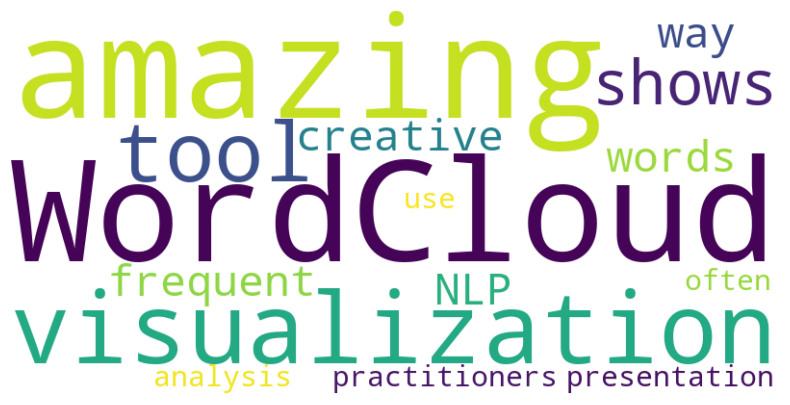

In [10]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = """WordCloud is an amazing visualization tool.
It shows the most frequent words in a creative way.
NLP practitioners often use it for analysis and presentation."""

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    colormap="viridis",
    max_words=100
).generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

## 🌟 Advanced WordCloud in NLP

While the basic WordCloud gives a quick view of frequent terms, advanced customization makes it more visually appealing and meaningful.  
You can use **shapes, colors, fonts, and masks** to design creative wordclouds for reports, dashboards, or presentations.  

---

### 🎭 Advanced Features
- **Mask Images** → Shape your wordcloud like a circle, heart, bird, or human silhouette.  
- **Custom Fonts** → Use stylish fonts to give a thematic feel.  
- **Color Maps** → Apply gradient color schemes such as `"cool"`, `"autumn"`, `"cividis"`.  
- **Contours** → Add outlines for more definition.  
- **Transparency** → Blend your wordcloud with background images.  

---

### 🖼️ Example: WordCloud with Mask Shape

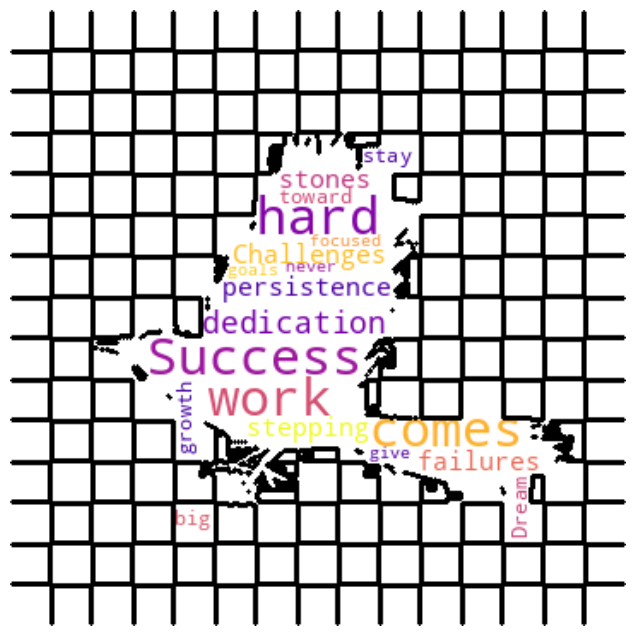

In [12]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# Load mask image (silhouette or shape)
mask = np.array(Image.open("bird.png"))  # Replace with your image file

text = """Success comes from hard work, dedication, and persistence.
Challenges and failures are stepping stones toward growth.
Dream big, stay focused, and never give up on your goals."""

# Generate masked wordcloud
wordcloud = WordCloud(
    width=800,
    height=800,
    background_color="white",
    mask=mask,
    contour_color="black",
    contour_width=2,
    colormap="plasma"
).generate(text)

# Display
plt.figure(figsize=(8, 8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

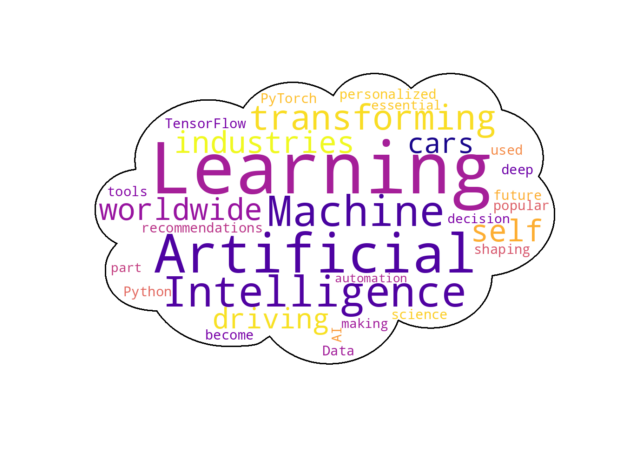

In [6]:
# pip install wordcloud matplotlib pillow numpy

from wordcloud import WordCloud
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# Load mask image (black & white or silhouette image)
mask = np.array(Image.open("cloud.png"))   # <-- replace with your shape image

# Sample text
text = """Artificial Intelligence and Machine Learning are transforming industries worldwide. 
From self-driving cars to personalized recommendations, AI is shaping the future. 
Python, TensorFlow, and PyTorch are popular tools used in deep learning. 
Data science has become an essential part of decision-making and automation.
"""

# Generate word cloud with mask
wordcloud = WordCloud(
    width=800,
    height=800,
    background_color="white",
    mask=mask,
    contour_color="black",
    contour_width=2,
    colormap="plasma"
).generate(text)

# Display the word cloud
plt.figure(figsize=(8, 8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()


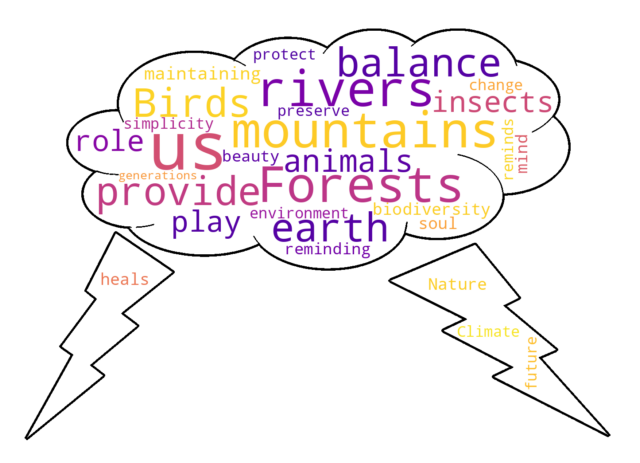

In [7]:
# pip install wordcloud matplotlib pillow numpy

from wordcloud import WordCloud
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# Load mask image (black & white or silhouette image)
mask = np.array(Image.open("cloud1.png"))   # <-- replace with your shape image

# Sample text
text = """Forests, rivers, and mountains provide balance to the earth. 
Birds, animals, and insects all play a role in maintaining biodiversity. 
Nature heals the mind and soul, reminding us of the beauty in simplicity. 
Climate change reminds us to protect and preserve our environment for future generations.
"""

# Generate word cloud with mask
wordcloud = WordCloud(
    width=800,
    height=800,
    background_color="white",
    mask=mask,
    contour_color="black",
    contour_width=2,
    colormap="plasma"
).generate(text)

# Display the word cloud
plt.figure(figsize=(8, 8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()


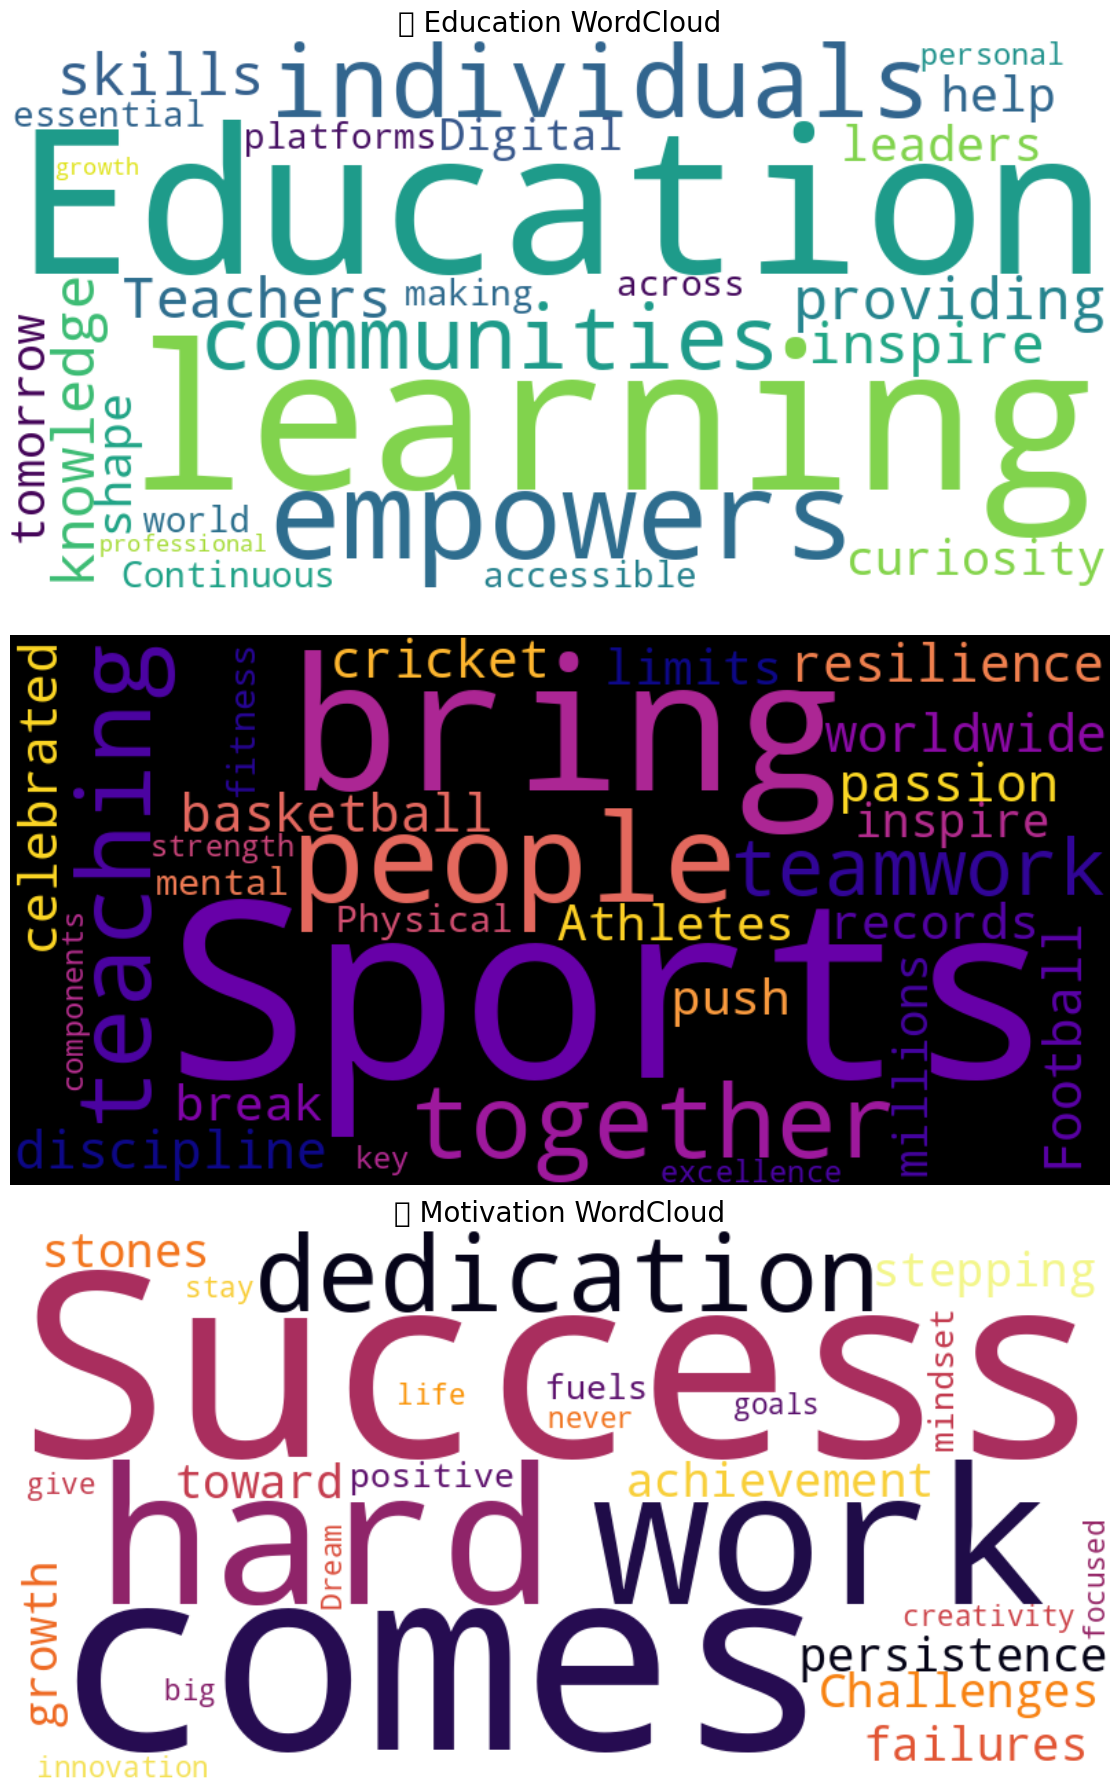

In [9]:
import warnings
warnings.filterwarnings("ignore")
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Text paragraphs
education_text = """Education empowers individuals and communities by providing knowledge and skills. 
Teachers inspire curiosity and help shape the leaders of tomorrow. 
Digital learning platforms are making education accessible across the world. 
Continuous learning is essential for personal and professional growth."""

sports_text = """Sports bring people together, teaching teamwork, discipline, and resilience. 
Football, cricket, and basketball are celebrated worldwide with passion. 
Athletes push their limits to break records and inspire millions. 
Physical fitness and mental strength are key components of sports excellence."""

motivation_text = """Success comes from hard work, dedication, and persistence. 
Challenges and failures are stepping stones toward growth and achievement. 
A positive mindset fuels creativity and innovation in life. 
Dream big, stay focused, and never give up on your goals."""

# Generate wordclouds with different styles
wc1 = WordCloud(width=800, height=400, background_color="white", colormap="viridis").generate(education_text)
wc2 = WordCloud(width=800, height=400, background_color="black", colormap="plasma").generate(sports_text)
wc3 = WordCloud(width=800, height=400, background_color="white", colormap="inferno").generate(motivation_text)

# Plot them side by side
fig, axs = plt.subplots(3, 1, figsize=(12, 18))

axs[0].imshow(wc1, interpolation="bilinear")
axs[0].set_title("📘 Education WordCloud", fontsize=20)
axs[0].axis("off")

axs[1].imshow(wc2, interpolation="bilinear")
axs[1].set_title("⚽ Sports WordCloud", fontsize=20, color="white")
axs[1].axis("off")

axs[2].imshow(wc3, interpolation="bilinear")
axs[2].set_title("🌟 Motivation WordCloud", fontsize=20)
axs[2].axis("off")

plt.tight_layout()
plt.show()

# Save images
wc1.to_file("education.png")
wc2.to_file("sports.png")
wc3.to_file("motivation.png")
